In [200]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
pd.set_option('display.max_columns', None)
import torch.optim as optim

In [201]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [202]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [203]:
df.shape

(1025, 14)

In [204]:
#Data Cleaning
df = df.dropna().drop_duplicates() #This will remove any row with missing values, then remove any duplicate rows, keeping only the first unique occurrence.
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [205]:
df.shape

(302, 14)

In [206]:
# Feature selection: Numeric + Categorical One-Hot
#numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
#categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
#X_num = df[numeric_cols].values
#X_cat = pd.get_dummies(df[categorical_cols], dtype=float).values
#X = np.hstack([X_num, X_cat])


In [207]:
X= df.iloc[:, :-1]
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2


In [208]:
X = X.values.astype(np.float32)
X

array([[52.,  1.,  0., ...,  2.,  2.,  3.],
       [53.,  1.,  0., ...,  0.,  0.,  3.],
       [70.,  1.,  0., ...,  0.,  0.,  3.],
       ...,
       [52.,  1.,  0., ...,  2.,  1.,  3.],
       [59.,  1.,  3., ...,  2.,  0.,  2.],
       [54.,  1.,  0., ...,  1.,  1.,  3.]], dtype=float32)

In [209]:
y = df['target'].values.astype(np.float32)
y

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0.,
       1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,
       1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 1., 0., 1., 0., 1., 0.,
       0., 1., 1., 0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0.,
       0., 1., 1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 1., 0.,
       0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       1., 0., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1.,
       0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 0., 0., 1., 1.,
       1., 1., 0., 1., 1., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 1.,
       1., 0., 0., 1., 1., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 1.,
       1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1.,
       1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.,
       1., 0., 1., 0., 1.

In [210]:
X.shape, y.shape

((302, 13), (302,))

In [211]:
# Normalization: fit only on numeric columns
scaler = StandardScaler()
X = scaler.fit_transform(X)
#y = y.reshape(-1, 1)
X.shape, y.shape

((302, 13), (302,))

In [212]:
X

array([[-0.26796588,  0.68265617, -0.93520796, ...,  0.9795145 ,
         1.27498   ,  1.1199666 ],
       [-0.15726042,  0.68265617, -0.93520796, ..., -2.2711818 ,
        -0.7149112 ,  1.1199666 ],
       [ 1.7247326 ,  0.68265617, -0.93520796, ..., -2.2711818 ,
        -0.7149112 ,  1.1199666 ],
       ...,
       [-0.26796588,  0.68265617, -0.93520796, ...,  0.9795145 ,
         0.28003436,  1.1199666 ],
       [ 0.5069724 ,  0.68265617,  1.9764706 , ...,  0.9795145 ,
        -0.7149112 , -0.51399434],
       [-0.04655495,  0.68265617, -0.93520796, ..., -0.6458337 ,
         0.28003436,  1.1199666 ]], dtype=float32)

In [213]:
# Split: train, val, test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [214]:
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((180, 13), (61, 13), (61, 13), (180,), (61,), (61,))

In [215]:
#In PyTorch, unsqueeze(dim) adds a new dimension of size 1 at the specified axis
# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [216]:
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

(torch.Size([180, 13]),
 torch.Size([61, 13]),
 torch.Size([61, 13]),
 torch.Size([180, 1]),
 torch.Size([61, 1]),
 torch.Size([61, 1]))

In [217]:
#TensorDataset combines features and labels tensors for easy indexing and retrieval during training.
#DataLoader wraps the dataset, enabling iteration over batches of data with size 64 here, which is useful for mini-batch gradient descent to speed up training and reduce memory usage.
#shuffle=True in train_loader ensures random shuffling of the training data every epoch to improve model generalization and avoid learning artifacts in the input order.
#Validation and test loaders usually do not shuffle data to provide consistent evaluation.
# DataLoader for batch learning
train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)
test_ds = TensorDataset(X_test, y_test)

In [218]:
train_ds

In [219]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

In [220]:
train_loader

In [221]:
X_train.shape[1]

13

In [222]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(X_train.shape[1], 16),  # Linear layer with input features = number of features in X_train, output=16
    nn.ReLU(),                        # Activation layer ReLU (non-linearity)
    nn.Linear(16, 1),                 # Linear layer from 16 to 1 output (binary classification or regression)
    nn.Sigmoid()                     # Sigmoid activation for output between 0 and 1 (good for binary classification)
)


In [223]:
# Optimizer and loss
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.BCELoss()

In [224]:
# Device handling
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [225]:
#model.train() sets the model to training mode enabling dropout, batch norm, etc..
#xb.size(0) is the mini-batch size (number of samples in this batch).
#Multiplying loss.item() by xb.size(0) gives the total loss for all samples in that batch.
#Finally, dividing by len(train_loader.dataset) (total number of samples in the dataset) gives the average loss per sample over the entire epoch.
# Training with validation


Epoch 1/800, Train Loss: 0.7202, Val Loss: 0.7175, Val Acc: 42.62%
Epoch 2/800, Train Loss: 0.7195, Val Loss: 0.7169, Val Acc: 42.62%
Epoch 3/800, Train Loss: 0.7188, Val Loss: 0.7162, Val Acc: 42.62%
Epoch 4/800, Train Loss: 0.7180, Val Loss: 0.7156, Val Acc: 42.62%
Epoch 5/800, Train Loss: 0.7173, Val Loss: 0.7150, Val Acc: 42.62%
Epoch 6/800, Train Loss: 0.7166, Val Loss: 0.7143, Val Acc: 42.62%
Epoch 7/800, Train Loss: 0.7158, Val Loss: 0.7137, Val Acc: 42.62%
Epoch 8/800, Train Loss: 0.7151, Val Loss: 0.7131, Val Acc: 42.62%
Epoch 9/800, Train Loss: 0.7144, Val Loss: 0.7124, Val Acc: 42.62%
Epoch 10/800, Train Loss: 0.7137, Val Loss: 0.7118, Val Acc: 42.62%
Epoch 11/800, Train Loss: 0.7129, Val Loss: 0.7112, Val Acc: 42.62%
Epoch 12/800, Train Loss: 0.7122, Val Loss: 0.7105, Val Acc: 42.62%
Epoch 13/800, Train Loss: 0.7115, Val Loss: 0.7099, Val Acc: 42.62%
Epoch 14/800, Train Loss: 0.7108, Val Loss: 0.7093, Val Acc: 42.62%
Epoch 15/800, Train Loss: 0.7100, Val Loss: 0.7087, Val A

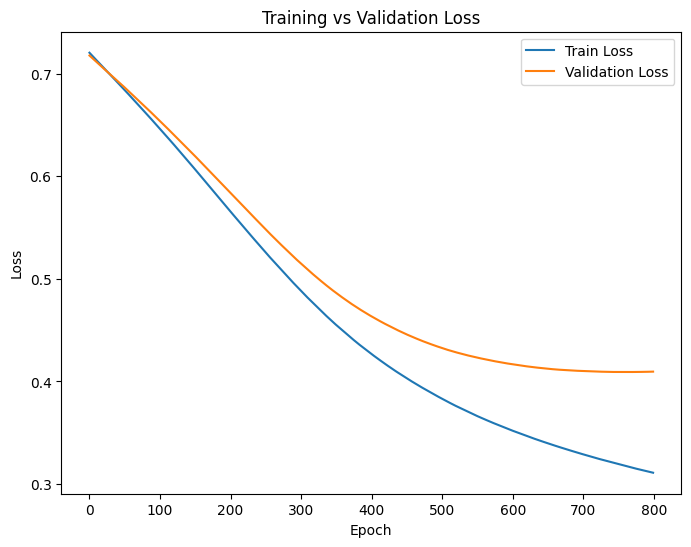

In [226]:
# Lists to store metrics for plotting
train_losses = []
val_losses = []
val_accuracies = []

# Training loop with validation
epochs = 800

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        yb = yb.float()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    val_acc = 0
    val_count = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            yb = yb.float()
            val_outputs = model(xb)
            loss = criterion(val_outputs, yb)
            val_loss += loss.item() * xb.size(0)
            preds = (val_outputs >= 0.5).float()
            val_acc += (preds == yb).float().sum().item()
            val_count += xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_acc = 100 * val_acc / val_count
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

# Plot train and val loss curves
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


In [230]:
# Test and report
model.eval()
test_loss, test_acc, test_count = 0, 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        test_outputs = model(xb)
        loss = criterion(test_outputs, yb)
        test_loss += loss.item() * xb.size(0)
        preds = (test_outputs >= 0.5).float()
        test_acc += (preds == yb).float().sum().item()
        test_count += xb.size(0)
test_loss /= len(test_loader.dataset)
test_acc = 100 * test_acc / test_count
print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

Test Loss: 0.4430, Test Acc: 83.61%


In [233]:
import torch

# Example: new sample feature vector (13 features matching your dataset)
# Replace with your actual data, make sure to scale properly as during training
new_sample = [63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]  # example raw data

# Convert to numpy array and reshape to (1, 13)
import numpy as np
new_sample_np = np.array(new_sample, dtype=np.float32).reshape(1, -1)

# Scale using the same scaler as training
new_sample_scaled = scaler.transform(new_sample_np)  # scaler was fit before training

# Convert to torch tensor and move to device (CPU/GPU)
new_sample_tensor = torch.tensor(new_sample_scaled, dtype=torch.float32).to(device)

# Put model in evaluation mode
model.eval()

with torch.no_grad():
    output = model(new_sample_tensor)  # model output is a probability because of Sigmoid layer
    prediction = (output >= 0.5).float()  # threshold to get class label 0 or 1

print(f"Prediction probability: {output.item():.4f}")
print(f"Predicted class: {int(prediction.item())}")


Prediction probability: 0.6120
Predicted class: 1
